# Startup Distribution in Portugal

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))
from unidecode import unidecode
import importlib
import src.maps
from IPython.display import Image
importlib.reload(src.maps)
from src.maps import get_geojson, plot_choropleth, get_gpd_dataframe

In [94]:
%run maps.ipynb #chart notebooks

In [95]:
#Global visual style
sns.set_style("whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

## 1. Introduction

Portugal's startup ecosystem has experienced significant growth in recent years, particularly around major urban centers such as Lisbon and Porto. This project explores the geographic distribution of startups across Portuguese municipalities and investigates whether socio-economic characteristics help explain these patterns.

## 2. Research Questions and Assumptions

The project is guided by the following research questions:

- How are startups distributed across Portugal?
- Is there significant geographic concentration?
- Which municipalities over or underperform?
- Which socio-economic factors appear associated with startups presence?

Initial assumptions:

- Startup activity is likely concentrated in Lisbon and Porto.
- Municipalities with higher purchasing power may attract more startups.
- Higher education levels may be associated with startup density. 

## 3. Data Sources

The project combines startup data from Dealroom with socio-economic indicators collected from PORDATA.

### Startup Data
- Municipality
- Funding
- Industry sector
- Founding year

### Socio-economic Data
- Population
- Population density
- Higher education rates
- Purchasing power
- Business creation metrics

## 4. Data Cleaning and Preparation

In [96]:
#Import startups dataset
startups_dataframe = pd.read_csv("../data/processed_data/startups_clean.csv")
print(startups_dataframe.head(20))

                        name hq_state     hq_city  total_funding_eur_m  \
0                     RDfine  Coimbra     Coimbra                  NaN   
1                  BackChain    Porto       Porto                  NaN   
2                  Liveplace   Guarda     Sabugal                  NaN   
3                  Inspiring   Lisboa      Lisboa                  NaN   
4              Events by tlc   Lisboa      Lisboa                  NaN   
5      Warrior Mata Clothing  Setúbal       Moita                  NaN   
6                     Nimest    Porto       Porto                  NaN   
7                    Ciengis  Coimbra     Coimbra                  NaN   
8                     TRED3D   Leiria      Leiria                  NaN   
9                      Flair   Lisboa      Lisboa                  NaN   
10                  FastDrop   Lisboa     Cascais                  NaN   
11                  Softrino   Lisboa      Lisboa                  NaN   
12                  Overcube    Braga 

In [97]:
#Importing unemployment dataset
socio_unemployment10k_dataframe = pd.read_csv("../data/processed_data/02_df_unemployment_p10k.csv")
print(socio_unemployment10k_dataframe.head())

  territory  year  population_total  unemployment_total  unemployment_female  \
0  Abrantes  2016             36421          512.643804           270.970045   
1  Abrantes  2017             35937          455.769819           243.175557   
2  Abrantes  2018             35463          397.343710           219.637369   
3  Abrantes  2019             35083          387.196078           216.572129   
4  Abrantes  2020             34745          435.458339           228.752338   

   unemployment_male  unemployment[<25]  unemployment[25-34]  \
0         241.673760          58.839680           101.672112   
1         212.594262          50.171133            90.269082   
2         177.706342          49.037025            74.415588   
3         170.652453          47.401876            72.485249   
4         206.706001          51.892359            89.538063   

   unemployment[35-44]  unemployment[45-54]  unemployment[>54]  \
0           123.774745           119.052195         109.305071   
1 

In [98]:
#Importing new company dataset
socio_new_company10k_dataframe = pd.read_csv("../data/processed_data/03_df_company_p10k.csv")
print(socio_new_company10k_dataframe.head())

  territory  year  population_total  company_total  company_individual  \
0  Abrantes  2016             36421     834.957854          587.023970   
1  Abrantes  2017             35937     873.751287          620.808637   
2  Abrantes  2018             35463     867.664890          611.341398   
3  Abrantes  2019             35083     879.058233          609.126928   
4  Abrantes  2020             34745     889.624406          608.145057   

   company_society  company_density  company_nr_cae_a  company_nr_cae_b  \
0       247.933884              4.3         83.742896               0.0   
1       252.942650              4.4         84.870746               0.0   
2       256.323492              4.3         87.133068               0.0   
3       269.931306              4.3         86.651655               0.0   
4       281.479350              4.3         86.055548               0.0   

   company_nr_cae_c  ...  company_gva_cae_n  company_gva_cae_p  \
0         40.086763  ...         943.6

In [99]:
#Importing education dataset
socio_university10k_dataframe = pd.read_csv("../data/processed_data/04_df_university_p10k.csv")
print(socio_university10k_dataframe.head())

  territory  year  population_total  university_total  university_poli  \
0  Abrantes  2016             36421         85.939431        85.939431   
1  Abrantes  2017             35937         87.096864        87.096864   
2  Abrantes  2018             35463         91.080845        91.080845   
3  Abrantes  2019             35083        102.328763       102.328763   
4  Abrantes  2020             34745        125.197870       125.197870   

   university_uni  university_public_total  university_public_poli  \
0             0.0                85.939431               85.939431   
1             0.0                87.096864               87.096864   
2             0.0                91.080845               91.080845   
3             0.0               102.328763              102.328763   
4             0.0               125.197870              125.197870   

   university_public_uni  university_private_total  ...  university_gl_ba  \
0                    0.0                       0.0  ...  

### Checking the shape of the dataframes

In [100]:
#Startups dataframe shape
startups_dataframe.shape

(3904, 16)

In [101]:
#unemployment shape
socio_unemployment10k_dataframe.shape


(2772, 17)

In [102]:
#new company shape
socio_new_company10k_dataframe.shape

(2772, 69)

In [103]:
#university shape
socio_university10k_dataframe.shape

(2772, 29)

### Checking the info of the dataframes

In [104]:
#Startup info
startups_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 3904 non-null   str    
 1   hq_state             3847 non-null   str    
 2   hq_city              3813 non-null   str    
 3   total_funding_eur_m  656 non-null    float64
 4   launch_year          3589 non-null   float64
 5   industries           3401 non-null   str    
 6   employees_range      3281 non-null   str    
 7   company_status       3889 non-null   str    
 8   hq_city_missing      3904 non-null   int64  
 9   hq_state_missing     3904 non-null   int64  
 10  primary_industry     3401 non-null   str    
 11  metro_area           3904 non-null   str    
 12  has_grant            3904 non-null   int64  
 13  has_vc               3904 non-null   int64  
 14  has_funding          3904 non-null   int64  
 15  startup_age          3589 non-null   float64
dtyp

In [105]:
#unemployment info
socio_unemployment10k_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   territory            2772 non-null   str    
 1   year                 2772 non-null   int64  
 2   population_total     2772 non-null   int64  
 3   unemployment_total   2772 non-null   float64
 4   unemployment_female  2772 non-null   float64
 5   unemployment_male    2772 non-null   float64
 6   unemployment[<25]    2772 non-null   float64
 7   unemployment[25-34]  2772 non-null   float64
 8   unemployment[35-44]  2772 non-null   float64
 9   unemployment[45-54]  2772 non-null   float64
 10  unemployment[>54]    2772 non-null   float64
 11  unemployment_el_b1   2772 non-null   float64
 12  unemployment_el_b2   2772 non-null   float64
 13  unemployment_el_b3   2772 non-null   float64
 14  unemployment_el_hs   2772 non-null   float64
 15  unemployment_el_c    2772 non-null   float64
 16 

In [106]:
#new company info
socio_new_company10k_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 69 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   territory                     2772 non-null   str    
 1   year                          2772 non-null   int64  
 2   population_total              2772 non-null   int64  
 3   company_total                 2772 non-null   float64
 4   company_individual            2772 non-null   float64
 5   company_society               2772 non-null   float64
 6   company_density               2772 non-null   float64
 7   company_nr_cae_a              2772 non-null   float64
 8   company_nr_cae_b              2772 non-null   float64
 9   company_nr_cae_c              2772 non-null   float64
 10  company_nr_cae_d              2772 non-null   float64
 11  company_nr_cae_e              2772 non-null   float64
 12  company_nr_cae_f              2772 non-null   float64
 13  company_nr_cae

In [107]:
#university info
socio_university10k_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   territory                 2772 non-null   str    
 1   year                      2772 non-null   int64  
 2   population_total          2772 non-null   int64  
 3   university_total          2772 non-null   float64
 4   university_poli           2772 non-null   float64
 5   university_uni            2772 non-null   float64
 6   university_public_total   2772 non-null   float64
 7   university_public_poli    2772 non-null   float64
 8   university_public_uni     2772 non-null   float64
 9   university_private_total  2772 non-null   float64
 10  university_private_poli   2772 non-null   float64
 11  university_private_uni    2772 non-null   float64
 12  university_gl_lic         2772 non-null   float64
 13  university_gl_lic1        2772 non-null   float64
 14  university_gl_ma   

### District names normalization in Startup Dataset

In [108]:
# normalize district names for startups
def normalize_district_names(column):
    return column.str.strip().str.title()  # Remove leading/trailing whitespace and convert to title case

#startup district names
startups_district_names_column = normalize_district_names(startups_dataframe['hq_state'])
#print(startups_district_names_column.head(20))


In [109]:
# normalize district names for unemployment data
socio_unemployment_district_names_column = normalize_district_names(socio_unemployment10k_dataframe['territory'])
print(socio_unemployment_district_names_column.head(20))

0            Abrantes
1            Abrantes
2            Abrantes
3            Abrantes
4            Abrantes
5            Abrantes
6            Abrantes
7            Abrantes
8            Abrantes
9     Aguiar Da Beira
10    Aguiar Da Beira
11    Aguiar Da Beira
12    Aguiar Da Beira
13    Aguiar Da Beira
14    Aguiar Da Beira
15    Aguiar Da Beira
16    Aguiar Da Beira
17    Aguiar Da Beira
18          Alandroal
19          Alandroal
Name: territory, dtype: str


In [110]:
# normalize district names for new company data data
socio_new_company_district_names_column = normalize_district_names(socio_new_company10k_dataframe['territory'])
print(socio_new_company_district_names_column.head(20))

0            Abrantes
1            Abrantes
2            Abrantes
3            Abrantes
4            Abrantes
5            Abrantes
6            Abrantes
7            Abrantes
8            Abrantes
9     Aguiar Da Beira
10    Aguiar Da Beira
11    Aguiar Da Beira
12    Aguiar Da Beira
13    Aguiar Da Beira
14    Aguiar Da Beira
15    Aguiar Da Beira
16    Aguiar Da Beira
17    Aguiar Da Beira
18          Alandroal
19          Alandroal
Name: territory, dtype: str


In [111]:
# normalize district names for university data
socio_university_district_names_column = normalize_district_names(socio_university10k_dataframe['territory'])
print(socio_university_district_names_column.head(20))

0            Abrantes
1            Abrantes
2            Abrantes
3            Abrantes
4            Abrantes
5            Abrantes
6            Abrantes
7            Abrantes
8            Abrantes
9     Aguiar Da Beira
10    Aguiar Da Beira
11    Aguiar Da Beira
12    Aguiar Da Beira
13    Aguiar Da Beira
14    Aguiar Da Beira
15    Aguiar Da Beira
16    Aguiar Da Beira
17    Aguiar Da Beira
18          Alandroal
19          Alandroal
Name: territory, dtype: str


In [112]:
#Checking regions in the startups dataset that are not in the socioeconomic datasets
print(sorted(set(startups_district_names_column.dropna()) - (set(socio_unemployment_district_names_column.dropna()))))
print("\n")
print(sorted(set(startups_district_names_column.dropna()) - (set(socio_new_company_district_names_column.dropna()))))
print("\n")
print(sorted(set(startups_district_names_column.dropna()) - (set(socio_university_district_names_column.dropna()))))

['Açores', 'Madeira']


['Açores', 'Madeira']


['Açores', 'Madeira']


In [113]:
#checking regions that are in the socioeconomic datasets but not in the startups dataset
print(sorted(set(socio_unemployment_district_names_column) - (set(startups_district_names_column))))
print("\n")
print(sorted(set(socio_new_company_district_names_column) - (set(startups_district_names_column))))
print("\n")
print(sorted(set(socio_university_district_names_column) - (set(startups_district_names_column))))

['Abrantes', 'Aguiar Da Beira', 'Alandroal', 'Albergaria-A-Velha', 'Albufeira', 'Alcanena', 'Alcobaça', 'Alcochete', 'Alcoutim', 'Alcácer Do Sal', 'Alenquer', 'Alfândega Da Fé', 'Alijó', 'Aljezur', 'Aljustrel', 'Almada', 'Almeida', 'Almeirim', 'Almodôvar', 'Alpiarça', 'Alter Do Chão', 'Alvaiázere', 'Alvito', 'Amadora', 'Amarante', 'Amares', 'Anadia', 'Angra Do Heroísmo', 'Ansião', 'Arcos De Valdevez', 'Arganil', 'Armamar', 'Arouca', 'Arraiolos', 'Arronches', 'Arruda Dos Vinhos', 'Avis', 'Azambuja', 'Baião', 'Barcelos', 'Barrancos', 'Barreiro', 'Batalha', 'Belmonte', 'Benavente', 'Bombarral', 'Borba', 'Boticas', 'Cabeceiras De Basto', 'Cadaval', 'Caldas Da Rainha', 'Calheta [R.A.A.]', 'Calheta [R.A.M.]', 'Caminha', 'Campo Maior', 'Cantanhede', 'Carrazeda De Ansiães', 'Carregal Do Sal', 'Cartaxo', 'Cascais', 'Castanheira De Pêra', 'Castelo De Paiva', 'Castelo De Vide', 'Castro Daire', 'Castro Marim', 'Castro Verde', 'Celorico Da Beira', 'Celorico De Basto', 'Chamusca', 'Chaves', 'Cinfães

### Checking unique and nunique municipalities

In [114]:
#checking unique and nunique startups
print("Number of unique districts in startups dataset:", startups_district_names_column.nunique())
print(f"they are, {startups_district_names_column.unique()}")
print("\n")
print("So it's missing in all the socio-economic datasets:", sorted(set(startups_district_names_column.dropna()) - (set(socio_unemployment_district_names_column.dropna()))))


Number of unique districts in startups dataset: 20
they are, <StringArray>
[         'Coimbra',            'Porto',           'Guarda',
           'Lisboa',          'Setúbal',           'Leiria',
            'Braga',           'Aveiro',          'Madeira',
           'Açores',   'Castelo Branco', 'Viana Do Castelo',
             'Faro',            'Évora',        'Vila Real',
         'Santarém',                nan,            'Viseu',
         'Bragança',             'Beja',       'Portalegre']
Length: 21, dtype: str


So it's missing in all the socio-economic datasets: ['Açores', 'Madeira']


In [115]:
#checking unique and nunique socioeconomic datasets
print("Number of unique districts in unemployment dataset:", socio_unemployment_district_names_column.nunique())
print(f"they are, {socio_unemployment_district_names_column.unique()}")
print("\n")
print("Number of unique districts in new company dataset:", socio_new_company_district_names_column.nunique())
print(f"they are, {socio_new_company_district_names_column.unique()}")
print("\n")
print("Number of unique districts in university dataset:", socio_university_district_names_column.nunique())
print(f"they are, {socio_university_district_names_column.unique()}")
print("\n")

print("So it's missing in startups dataset:", sorted(set(socio_unemployment_district_names_column.dropna()) - (set(startups_district_names_column.dropna()))))
print("A total of", len(sorted(set(socio_unemployment_district_names_column.dropna()) - (set(startups_district_names_column.dropna())))), "districts are missing in startups dataset compared to socio-economic datasets.")

Number of unique districts in unemployment dataset: 308
they are, <StringArray>
[          'Abrantes',    'Aguiar Da Beira',          'Alandroal',
 'Albergaria-A-Velha',          'Albufeira',           'Alcanena',
           'Alcobaça',          'Alcochete',           'Alcoutim',
     'Alcácer Do Sal',
 ...
      'Vila Do Porto',            'Vimioso',            'Vinhais',
              'Viseu',             'Vizela',            'Vouzela',
             'Águeda',              'Évora',             'Ílhavo',
             'Óbidos']
Length: 308, dtype: str


Number of unique districts in new company dataset: 308
they are, <StringArray>
[          'Abrantes',    'Aguiar Da Beira',          'Alandroal',
 'Albergaria-A-Velha',          'Albufeira',           'Alcanena',
           'Alcobaça',          'Alcochete',           'Alcoutim',
     'Alcácer Do Sal',
 ...
      'Vila Do Porto',            'Vimioso',            'Vinhais',
              'Viseu',             'Vizela',            'Vouzela',

### Geographic Granularity

> The startup dataset was available at district/regional level rather than municipality level. Therefore, socio-economic datasets were aggregated to the same geographic granularity to ensure consistency across analyses.

### Normalize municipality names for socioeconomic data at District Level

In [116]:
# importing the dataset and extract just the municipality names from the startups dataset to compare with socio-economic datasets
nuts_dataframe = pd.read_csv("../data/processed_data/00_df_nuts.csv")
nuts_dataframe.head()

,nuts_1_code,nuts_1,nuts_2_code,nuts_2,nuts_3_code,nuts_3,region,territory
0,PT1,Portugal Continental,PT11,Região do Norte,PT111,Alto Minho,Viana do Castelo,Arcos de Valdevez
1,PT1,Portugal Continental,PT11,Região do Norte,PT111,Alto Minho,Viana do Castelo,Caminha
2,PT1,Portugal Continental,PT11,Região do Norte,PT111,Alto Minho,Viana do Castelo,Melgaço
3,PT1,Portugal Continental,PT11,Região do Norte,PT111,Alto Minho,Viana do Castelo,Monção
4,PT1,Portugal Continental,PT11,Região do Norte,PT111,Alto Minho,Viana do Castelo,Paredes de Coura


In [117]:
#Checking the shape of the nuts dataframe
nuts_dataframe.shape

(308, 8)

In [118]:
#Checking the info of the nuts dataframe
nuts_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   nuts_1_code  308 non-null    str  
 1   nuts_1       308 non-null    str  
 2   nuts_2_code  308 non-null    str  
 3   nuts_2       308 non-null    str  
 4   nuts_3_code  308 non-null    str  
 5   nuts_3       308 non-null    str  
 6   region       308 non-null    str  
 7   territory    308 non-null    str  
dtypes: str(8)
memory usage: 19.4 KB


In [119]:
#Copy the nuts dataframe and extract just the region column
nuts_region_dataframe = nuts_dataframe.copy()
nuts_region_dataframe = nuts_region_dataframe[['region', 'territory']]
nuts_region_dataframe.head()

,region,territory
0,Viana do Castelo,Arcos de Valdevez
1,Viana do Castelo,Caminha
2,Viana do Castelo,Melgaço
3,Viana do Castelo,Monção
4,Viana do Castelo,Paredes de Coura


In [120]:
#region column normalization
def normalize_region_names(columns):
    return columns.apply(lambda x: x.str.strip().str.title())  # Remove leading/trailing whitespace and convert to title case
nuts_region_dataframe[['region', 'territory']] = normalize_region_names(nuts_region_dataframe[['region', 'territory']])
nuts_region_dataframe.head()

,region,territory
0,Viana Do Castelo,Arcos De Valdevez
1,Viana Do Castelo,Caminha
2,Viana Do Castelo,Melgaço
3,Viana Do Castelo,Monção
4,Viana Do Castelo,Paredes De Coura


In [121]:
# We already have 2 region columns on the other socio-economic datasets (region_x and region_y) with a lot of missing values, so we will remove both and take only the region column from the nuts dataset to merge with the socio-economic datasets.
#socio_unemployment10k_dataframe["region_x"].isna().sum() #commented because they were already removed.
#socio_unemployment10k_dataframe["region_y"].isna().sum() #commented because they were already removed.
socio_unemployment10k_dataframe = (
    socio_unemployment10k_dataframe
    .drop(columns=["region_x", "region_y"], errors="ignore")
)


In [122]:
socio_new_company10k_dataframe = (
    socio_new_company10k_dataframe
    .drop(columns=["region_x", "region_y"], errors="ignore")
)

In [123]:
socio_university10k_dataframe = (
    socio_university10k_dataframe
    .drop(columns=["region"], errors="ignore")
)

In [124]:
#Checking that both columns were removed
print("Unemployment dataset columns:", socio_unemployment10k_dataframe.columns)

Unemployment dataset columns: Index(['territory', 'year', 'population_total', 'unemployment_total',
       'unemployment_female', 'unemployment_male', 'unemployment[<25]',
       'unemployment[25-34]', 'unemployment[35-44]', 'unemployment[45-54]',
       'unemployment[>54]', 'unemployment_el_b1', 'unemployment_el_b2',
       'unemployment_el_b3', 'unemployment_el_hs', 'unemployment_el_c',
       'unemployment_el_ne'],
      dtype='str')


In [125]:
#Checking that both columns were removed
print("New company dataset columns:", socio_new_company10k_dataframe.columns)


New company dataset columns: Index(['territory', 'year', 'population_total', 'company_total',
       'company_individual', 'company_society', 'company_density',
       'company_nr_cae_a', 'company_nr_cae_b', 'company_nr_cae_c',
       'company_nr_cae_d', 'company_nr_cae_e', 'company_nr_cae_f',
       'company_nr_cae_g', 'company_nr_cae_h', 'company_nr_cae_i',
       'company_nr_cae_j', 'company_nr_cae_l', 'company_nr_cae_m',
       'company_nr_cae_n', 'company_nr_cae_p', 'company_nr_cae_q',
       'company_nr_cae_r', 'company_nr_cae_s', 'company_nr_employee_[<10]',
       'company_nr_employee_[10-19]', 'company_nr_employee_[20-49]',
       'company_nr_employee_[50-249]', 'company_nr_employee_[>249]',
       'company_employee_nr_cae_a', 'company_employee_nr_cae_b',
       'company_employee_nr_cae_c', 'company_employee_nr_cae_d',
       'company_employee_nr_cae_e', 'company_employee_nr_cae_f',
       'company_employee_nr_cae_g', 'company_employee_nr_cae_h',
       'company_employee_nr_ca

In [126]:
# checking that column "region" was removed
print("University dataset columns:", socio_university10k_dataframe.columns)

University dataset columns: Index(['territory', 'year', 'population_total', 'university_total',
       'university_poli', 'university_uni', 'university_public_total',
       'university_public_poli', 'university_public_uni',
       'university_private_total', 'university_private_poli',
       'university_private_uni', 'university_gl_lic', 'university_gl_lic1',
       'university_gl_ma', 'university_gl_phd', 'university_gl_spc',
       'university_gl_esp', 'university_gl_fc', 'university_gl_ba',
       'university_gl_htc', 'university_sa_a', 'university_sa_ah',
       'university_sa_sscl', 'university_sa_smi', 'university_sa_e',
       'university_sa_eic', 'university_sa_hsp', 'university_sa_s'],
      dtype='str')


In [127]:
#Normalize Territory column in the socio-economic datasets to match the territory column in the nuts dataset
socio_unemployment10k_dataframe['territory'] = socio_unemployment10k_dataframe['territory'].str.strip().str.title()

In [128]:
socio_new_company10k_dataframe['territory'] = socio_new_company10k_dataframe['territory'].str.strip().str.title()

In [129]:
socio_university10k_dataframe['territory'] = socio_university10k_dataframe['territory'].str.strip().str.title()

## 5. Feature Engineering

In [130]:
#Merging NUTS data into socioeconomic dataframes to get the region information for each municipality

socio_unemployment10k_dataframe = (
    socio_unemployment10k_dataframe.merge(
        nuts_region_dataframe[["territory", "region"]],
        on="territory",
        how="left"
    )
)
socio_unemployment10k_dataframe.head()


,territory,year,population_total,unemployment_total,unemployment_female,unemployment_male,unemployment[<25],unemployment[25-34],unemployment[35-44],unemployment[45-54],unemployment[>54],unemployment_el_b1,unemployment_el_b2,unemployment_el_b3,unemployment_el_hs,unemployment_el_c,unemployment_el_ne,region
0,Abrantes,2016,36421,512.643804,270.970045,241.673760,58.839680,101.672112,123.774745,119.052195,109.305071,90.826721,78.114275,123.994399,131.160594,58.620027,29.955246,Santarém
1,Abrantes,2017,35937,455.769819,243.175557,212.594262,50.171133,90.269082,105.406684,107.994546,101.928375,70.707071,69.510532,115.591173,115.535520,54.345104,30.080419,Santarém
2,Abrantes,2018,35463,397.343710,219.637369,177.706342,49.037025,74.415588,87.386854,93.618701,92.857344,61.613513,60.429180,95.282407,106.110594,45.850605,28.085610,Santarém
3,Abrantes,2019,35083,387.196078,216.572129,170.652453,47.401876,72.485249,83.772767,85.625517,97.939173,53.957757,61.226235,101.644671,105.578200,42.299689,22.518029,Santarém
4,Abrantes,2020,34745,435.458339,228.752338,206.706001,51.892359,89.538063,93.049360,91.178587,109.828752,57.331990,63.807742,111.382933,132.076558,47.517628,23.370269,Santarém


In [131]:
socio_new_company10k_dataframe = (
    socio_new_company10k_dataframe.merge(
        nuts_region_dataframe[["territory", "region"]],
        on="territory",
        how="left"
    )
)

socio_new_company10k_dataframe.head()

,territory,year,population_total,company_total,company_individual,company_society,company_density,company_nr_cae_a,company_nr_cae_b,company_nr_cae_c,...,company_gva_cae_p,company_gva_cae_q,company_gva_cae_r,company_gva_cae_s,company_gva_total,company_births_af,company_births_ice,company_births_s,company_births_total,region
0,Abrantes,2016,36421,834.957854,587.023970,247.933884,4.3,83.742896,0.0,40.086763,...,292.688284,1694.077593,117.789188,442.052662,71508.195821,15.101178,20.592515,96.922105,132.615799,Santarém
1,Abrantes,2017,35937,873.751287,620.808637,252.942650,4.4,84.870746,0.0,43.965829,...,294.125831,1781.450872,105.740602,461.641205,74182.040794,13.634972,13.634972,101.288366,128.558310,Santarém
2,Abrantes,2018,35463,867.664890,611.341398,256.323492,4.3,87.133068,0.0,43.989510,...,311.028396,1783.831035,124.354962,409.722810,75449.341567,13.817218,10.433409,78.391563,102.642190,Santarém
3,Abrantes,2019,35083,879.058233,609.126928,269.931306,4.3,86.651655,0.0,45.321096,...,304.705983,1977.310948,144.229399,449.790497,75121.853889,14.821994,8.551150,90.642191,114.015335,Santarém
4,Abrantes,2020,34745,889.624406,608.145057,281.479350,4.3,86.055548,0.0,42.308246,...,262.195999,2000.000000,90.660527,539.358181,69422.362930,9.785581,7.195280,90.372715,107.353576,Santarém


In [132]:
socio_university10k_dataframe = (
    socio_university10k_dataframe.merge(
        nuts_region_dataframe[["territory", "region"]],
        on="territory",
        how="left"
    )
)

socio_university10k_dataframe.head()


,territory,year,population_total,university_total,university_poli,university_uni,university_public_total,university_public_poli,university_public_uni,university_private_total,...,university_gl_htc,university_sa_a,university_sa_ah,university_sa_sscl,university_sa_smi,university_sa_e,university_sa_eic,university_sa_hsp,university_sa_s,region
0,Abrantes,2016,36421,85.939431,85.939431,0.0,85.939431,85.939431,0.0,0.0,...,9.335274,0.0,15.375745,23.338184,16.199445,0.0,31.026056,0.0,0.0,Santarém
1,Abrantes,2017,35937,87.096864,87.096864,0.0,87.096864,87.096864,0.0,0.0,...,18.643738,0.0,19.478532,23.374238,18.922002,0.0,25.322091,0.0,0.0,Santarém
2,Abrantes,2018,35463,91.080845,91.080845,0.0,91.080845,91.080845,0.0,0.0,...,21.430787,0.0,21.994755,24.250627,12.407298,0.0,32.428165,0.0,0.0,Santarém
3,Abrantes,2019,35083,102.328763,102.328763,0.0,102.328763,102.328763,0.0,0.0,...,31.639255,0.0,25.938489,25.083374,20.522760,0.0,30.784140,0.0,0.0,Santarém
4,Abrantes,2020,34745,125.197870,125.197870,0.0,125.197870,125.197870,0.0,0.0,...,47.201036,0.0,37.415455,31.083609,28.493308,0.0,28.205497,0.0,0.0,Santarém


In [133]:
#reorder the columns so Territory and Region are next to each other
cols = socio_unemployment10k_dataframe.columns.tolist()
new_order = ['territory', 'region'] + [col for col in cols if col not in ['territory', 'region']]
socio_unemployment10k_dataframe = socio_unemployment10k_dataframe[new_order]
socio_unemployment10k_dataframe.head()

,territory,region,year,population_total,unemployment_total,unemployment_female,unemployment_male,unemployment[<25],unemployment[25-34],unemployment[35-44],unemployment[45-54],unemployment[>54],unemployment_el_b1,unemployment_el_b2,unemployment_el_b3,unemployment_el_hs,unemployment_el_c,unemployment_el_ne
0,Abrantes,Santarém,2016,36421,512.643804,270.970045,241.673760,58.839680,101.672112,123.774745,119.052195,109.305071,90.826721,78.114275,123.994399,131.160594,58.620027,29.955246
1,Abrantes,Santarém,2017,35937,455.769819,243.175557,212.594262,50.171133,90.269082,105.406684,107.994546,101.928375,70.707071,69.510532,115.591173,115.535520,54.345104,30.080419
2,Abrantes,Santarém,2018,35463,397.343710,219.637369,177.706342,49.037025,74.415588,87.386854,93.618701,92.857344,61.613513,60.429180,95.282407,106.110594,45.850605,28.085610
3,Abrantes,Santarém,2019,35083,387.196078,216.572129,170.652453,47.401876,72.485249,83.772767,85.625517,97.939173,53.957757,61.226235,101.644671,105.578200,42.299689,22.518029
4,Abrantes,Santarém,2020,34745,435.458339,228.752338,206.706001,51.892359,89.538063,93.049360,91.178587,109.828752,57.331990,63.807742,111.382933,132.076558,47.517628,23.370269


In [134]:
#reorder the columns so Territory and Region are next to each other
cols2 = socio_new_company10k_dataframe.columns.tolist()
new_order2 = ['territory', 'region'] + [col for col in cols2 if col not in ['territory', 'region']]
socio_new_company10k_dataframe = socio_new_company10k_dataframe[new_order2]
socio_new_company10k_dataframe.head()

,territory,region,year,population_total,company_total,company_individual,company_society,company_density,company_nr_cae_a,company_nr_cae_b,...,company_gva_cae_n,company_gva_cae_p,company_gva_cae_q,company_gva_cae_r,company_gva_cae_s,company_gva_total,company_births_af,company_births_ice,company_births_s,company_births_total
0,Abrantes,Santarém,2016,36421,834.957854,587.023970,247.933884,4.3,83.742896,0.0,...,943.686335,292.688284,1694.077593,117.789188,442.052662,71508.195821,15.101178,20.592515,96.922105,132.615799
1,Abrantes,Santarém,2017,35937,873.751287,620.808637,252.942650,4.4,84.870746,0.0,...,958.900298,294.125831,1781.450872,105.740602,461.641205,74182.040794,13.634972,13.634972,101.288366,128.558310
2,Abrantes,Santarém,2018,35463,867.664890,611.341398,256.323492,4.3,87.133068,0.0,...,803.654513,311.028396,1783.831035,124.354962,409.722810,75449.341567,13.817218,10.433409,78.391563,102.642190
3,Abrantes,Santarém,2019,35083,879.058233,609.126928,269.931306,4.3,86.651655,0.0,...,764.472822,304.705983,1977.310948,144.229399,449.790497,75121.853889,14.821994,8.551150,90.642191,114.015335
4,Abrantes,Santarém,2020,34745,889.624406,608.145057,281.479350,4.3,86.055548,0.0,...,643.545834,262.195999,2000.000000,90.660527,539.358181,69422.362930,9.785581,7.195280,90.372715,107.353576


In [135]:
#reorder the columns so Territory and Region are next to each other
cols3 = socio_university10k_dataframe.columns.tolist()
new_order3 = ['territory', 'region'] + [col for col in cols3 if col not in ['territory', 'region']]
socio_university10k_dataframe = socio_university10k_dataframe[new_order3]
socio_university10k_dataframe.head()

,territory,region,year,population_total,university_total,university_poli,university_uni,university_public_total,university_public_poli,university_public_uni,...,university_gl_ba,university_gl_htc,university_sa_a,university_sa_ah,university_sa_sscl,university_sa_smi,university_sa_e,university_sa_eic,university_sa_hsp,university_sa_s
0,Abrantes,Santarém,2016,36421,85.939431,85.939431,0.0,85.939431,85.939431,0.0,...,0.0,9.335274,0.0,15.375745,23.338184,16.199445,0.0,31.026056,0.0,0.0
1,Abrantes,Santarém,2017,35937,87.096864,87.096864,0.0,87.096864,87.096864,0.0,...,0.0,18.643738,0.0,19.478532,23.374238,18.922002,0.0,25.322091,0.0,0.0
2,Abrantes,Santarém,2018,35463,91.080845,91.080845,0.0,91.080845,91.080845,0.0,...,0.0,21.430787,0.0,21.994755,24.250627,12.407298,0.0,32.428165,0.0,0.0
3,Abrantes,Santarém,2019,35083,102.328763,102.328763,0.0,102.328763,102.328763,0.0,...,0.0,31.639255,0.0,25.938489,25.083374,20.522760,0.0,30.784140,0.0,0.0
4,Abrantes,Santarém,2020,34745,125.197870,125.197870,0.0,125.197870,125.197870,0.0,...,0.0,47.201036,0.0,37.415455,31.083609,28.493308,0.0,28.205497,0.0,0.0


In [136]:
#checking null values in the region column for unemployment dataset after the merge
print("Null values in region column of unemployment dataset:", socio_unemployment10k_dataframe['region'].isna().sum())

Null values in region column of unemployment dataset: 0


In [137]:
#checking null values in the region column for new company dataset after the merge
print("Null values in region column of new company dataset:", socio_new_company10k_dataframe['region'].isna().sum())

Null values in region column of new company dataset: 0


In [138]:
#checking null values in the region column for university dataset after the merge
print("Null values in region column of university dataset:", socio_university10k_dataframe['region'].isna().sum())

Null values in region column of university dataset: 0


### Filtering socio-economic datasets by year 2023

> To ensure temporal consistency across datasets, the analysis focused on 2023, the latest year consistently available across the startup and socio-economic data sources.

In [139]:
#Filtering unemployment dataset to year 2023
socio_unemployment10k_dataframe = (
    socio_unemployment10k_dataframe[
        socio_unemployment10k_dataframe["year"] == 2023
    ]
)

socio_unemployment10k_dataframe.head()

,territory,region,year,population_total,unemployment_total,unemployment_female,unemployment_male,unemployment[<25],unemployment[25-34],unemployment[35-44],unemployment[45-54],unemployment[>54],unemployment_el_b1,unemployment_el_b2,unemployment_el_b3,unemployment_el_hs,unemployment_el_c,unemployment_el_ne
7,Abrantes,Santarém,2023,33835,336.810995,181.734890,155.076105,46.342545,63.307226,61.829467,68.863603,96.497709,37.653318,45.721886,78.735038,115.649475,36.589331,22.491503
16,Aguiar Da Beira,Guarda,2023,5293,167.013036,80.294729,86.718307,20.215379,26.450028,36.085396,27.394672,57.056490,27.961459,27.961459,25.127527,46.476478,24.560741,14.925373
25,Alandroal,Évora,2023,5003,166.899860,99.540276,67.359584,19.988007,19.188487,32.980212,45.372776,49.570258,32.180692,26.184289,31.581051,49.370378,21.187288,6.596042
34,Albergaria-A-Velha,Aveiro,2023,25552,197.988416,127.739512,70.248904,23.481528,37.961803,44.575767,43.949593,48.058860,21.876957,31.152160,41.953663,65.122104,21.055103,16.867564
43,Albufeira,Faro,2023,47019,484.591335,250.770965,233.820370,47.661584,143.431379,113.315894,88.666284,91.516196,28.350241,46.023948,87.198792,240.115698,23.309726,59.614199


In [140]:
#Filtering new company dataset to year 2023
socio_new_company10k_dataframe = (
    socio_new_company10k_dataframe[
        socio_new_company10k_dataframe["year"] == 2023
    ]
)

socio_new_company10k_dataframe.head()

,territory,region,year,population_total,company_total,company_individual,company_society,company_density,company_nr_cae_a,company_nr_cae_b,...,company_gva_cae_n,company_gva_cae_p,company_gva_cae_q,company_gva_cae_r,company_gva_cae_s,company_gva_total,company_births_af,company_births_ice,company_births_s,company_births_total
7,Abrantes,Santarém,2023,33835,980.345796,657.307522,323.038274,4.6,84.527856,0.000000,...,963.203783,402.541747,3024.383035,272.794444,809.221221,66312.102852,10.344318,14.186493,118.811881,143.342692
16,Aguiar Da Beira,Guarda,2023,5293,1447.194408,954.090308,493.104100,3.7,436.425468,5.667863,...,323.068203,232.382392,3287.360665,202.153788,593.236350,67679.954657,41.564330,9.446439,75.571510,126.582278
25,Alandroal,Évora,2023,5003,1363.182091,977.413552,385.768539,1.3,447.731361,5.996402,...,889.466320,189.886068,743.553868,635.618629,747.551469,29886.068359,33.979612,15.990406,89.946032,139.916050
34,Albergaria-A-Velha,Aveiro,2023,25552,1224.561678,848.465874,376.095805,19.7,97.056982,0.391359,...,2067.548528,0.000000,1594.787101,213.290545,609.345648,139755.792110,12.914840,22.698810,143.237320,178.850971
43,Albufeira,Faro,2023,47019,2495.161530,1746.740679,748.420851,83.4,81.243753,0.212680,...,9461.919650,707.586295,2865.224696,3422.020885,1106.148578,156371.892214,11.697399,54.020715,479.593356,545.311470


In [141]:
#Filtering education dataset to year 2023
socio_university10k_dataframe = (
    socio_university10k_dataframe[
        socio_university10k_dataframe["year"] == 2023
    ]
)

socio_university10k_dataframe.head()

,territory,region,year,population_total,university_total,university_poli,university_uni,university_public_total,university_public_poli,university_public_uni,...,university_gl_ba,university_gl_htc,university_sa_a,university_sa_ah,university_sa_sscl,university_sa_smi,university_sa_e,university_sa_eic,university_sa_hsp,university_sa_s
7,Abrantes,Santarém,2023,33835,139.204965,139.204965,0.0,139.204965,139.204965,0.0,...,0.0,54.086006,0.0,40.490616,31.032954,36.352889,0.0,31.328506,0.0,0.0
16,Aguiar Da Beira,Guarda,2023,5293,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
25,Alandroal,Évora,2023,5003,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
34,Albergaria-A-Velha,Aveiro,2023,25552,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
43,Albufeira,Faro,2023,47019,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0


### Normalizing again the filtered socio-economic datasets by year 2023

In [142]:
#Normalize Territory column in the socio-economic datasets filtered to year 2023 to match the territory column in the nuts dataset
socio_unemployment10k_dataframe["territory"] = socio_unemployment10k_dataframe["territory"].str.strip().str.title()

In [143]:
#Normalize Territory column in the socio-economic datasets filtered to year 2023 to match the territory column in the nuts dataset
socio_new_company10k_dataframe["territory"] = socio_new_company10k_dataframe["territory"].str.strip().str.title()

In [144]:
#Normalize Territory column in the socio-economic datasets filtered to year 2023 to match the territory column in the nuts dataset
socio_university10k_dataframe["territory"] = socio_university10k_dataframe["territory"].str.strip().str.title()

In [145]:
#removing region column region because it was already created previously.
socio_unemployment10k_dataframe = (
    socio_unemployment10k_dataframe
    .drop(columns=["region"], errors="ignore")
)

In [146]:
#Merging NUTS data into socioeconomic dataframes filtered to year 2023 to get the region information for each municipality
socio_unemployment10k_dataframe = (
    socio_unemployment10k_dataframe.merge(
        nuts_region_dataframe[["territory", "region"]],
        on="territory",
        how="left"
    )
)

socio_unemployment10k_dataframe.head()

,territory,year,population_total,unemployment_total,unemployment_female,unemployment_male,unemployment[<25],unemployment[25-34],unemployment[35-44],unemployment[45-54],unemployment[>54],unemployment_el_b1,unemployment_el_b2,unemployment_el_b3,unemployment_el_hs,unemployment_el_c,unemployment_el_ne,region
0,Abrantes,2023,33835,336.810995,181.734890,155.076105,46.342545,63.307226,61.829467,68.863603,96.497709,37.653318,45.721886,78.735038,115.649475,36.589331,22.491503,Santarém
1,Aguiar Da Beira,2023,5293,167.013036,80.294729,86.718307,20.215379,26.450028,36.085396,27.394672,57.056490,27.961459,27.961459,25.127527,46.476478,24.560741,14.925373,Guarda
2,Alandroal,2023,5003,166.899860,99.540276,67.359584,19.988007,19.188487,32.980212,45.372776,49.570258,32.180692,26.184289,31.581051,49.370378,21.187288,6.596042,Évora
3,Albergaria-A-Velha,2023,25552,197.988416,127.739512,70.248904,23.481528,37.961803,44.575767,43.949593,48.058860,21.876957,31.152160,41.953663,65.122104,21.055103,16.867564,Aveiro
4,Albufeira,2023,47019,484.591335,250.770965,233.820370,47.661584,143.431379,113.315894,88.666284,91.516196,28.350241,46.023948,87.198792,240.115698,23.309726,59.614199,Faro


In [147]:
#removing region column region because it was already created previously.
socio_new_company10k_dataframe = (
    socio_new_company10k_dataframe
    .drop(columns=["region"], errors="ignore")
)

In [148]:
#Merging NUTS data into socioeconomic dataframes filtered to year 2023 to get the region information for each municipality
socio_new_company10k_dataframe = (
    socio_new_company10k_dataframe.merge(
        nuts_region_dataframe[["territory", "region"]],
        on="territory",
        how="left"
    )
)

socio_new_company10k_dataframe.head()

,territory,year,population_total,company_total,company_individual,company_society,company_density,company_nr_cae_a,company_nr_cae_b,company_nr_cae_c,...,company_gva_cae_p,company_gva_cae_q,company_gva_cae_r,company_gva_cae_s,company_gva_total,company_births_af,company_births_ice,company_births_s,company_births_total,region
0,Abrantes,2023,33835,980.345796,657.307522,323.038274,4.6,84.527856,0.000000,50.834934,...,402.541747,3024.383035,272.794444,809.221221,66312.102852,10.344318,14.186493,118.811881,143.342692,Santarém
1,Aguiar Da Beira,2023,5293,1447.194408,954.090308,493.104100,3.7,436.425468,5.667863,71.792934,...,232.382392,3287.360665,202.153788,593.236350,67679.954657,41.564330,9.446439,75.571510,126.582278,Guarda
2,Alandroal,2023,5003,1363.182091,977.413552,385.768539,1.3,447.731361,5.996402,87.947232,...,189.886068,743.553868,635.618629,747.551469,29886.068359,33.979612,15.990406,89.946032,139.916050,Évora
3,Albergaria-A-Velha,2023,25552,1224.561678,848.465874,376.095805,19.7,97.056982,0.391359,106.840952,...,0.000000,1594.787101,213.290545,609.345648,139755.792110,12.914840,22.698810,143.237320,178.850971,Aveiro
4,Albufeira,2023,47019,2495.161530,1746.740679,748.420851,83.4,81.243753,0.212680,31.263957,...,707.586295,2865.224696,3422.020885,1106.148578,156371.892214,11.697399,54.020715,479.593356,545.311470,Faro


In [149]:
#removing region column region because it was already created previously.
socio_university10k_dataframe = (
    socio_university10k_dataframe
    .drop(columns=["region"], errors="ignore")
)

In [150]:
#Merging NUTS data into socioeconomic dataframes filtered to year 2023 to get the region information for each municipality
socio_university10k_dataframe = (
    socio_university10k_dataframe.merge(
        nuts_region_dataframe[["territory", "region"]],
        on="territory",
        how="left"
    )
)

socio_university10k_dataframe.head()

,territory,year,population_total,university_total,university_poli,university_uni,university_public_total,university_public_poli,university_public_uni,university_private_total,...,university_gl_htc,university_sa_a,university_sa_ah,university_sa_sscl,university_sa_smi,university_sa_e,university_sa_eic,university_sa_hsp,university_sa_s,region
0,Abrantes,2023,33835,139.204965,139.204965,0.0,139.204965,139.204965,0.0,0.0,...,54.086006,0.0,40.490616,31.032954,36.352889,0.0,31.328506,0.0,0.0,Santarém
1,Aguiar Da Beira,2023,5293,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Guarda
2,Alandroal,2023,5003,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Évora
3,Albergaria-A-Velha,2023,25552,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Aveiro
4,Albufeira,2023,47019,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,Faro


### Aggregating socio-economic datasets by region

In [151]:
#Total Unemployment aggregation by region in 2023
regional_unemployment = (
    socio_unemployment10k_dataframe
    .groupby(["region"])
    .agg({
        "unemployment_total": "mean"
    })
    .reset_index()
)

sorted_regional_unemployment = regional_unemployment.sort_values(by="unemployment_total", ascending=False)
sorted_regional_unemployment.head()

,region,unemployment_total
17,Vila Real,448.071538
1,Beja,375.026143
18,Viseu,355.950147
3,Bragança,351.962052
11,Porto,337.530837


In [152]:
#New company aggregation by region in 2023
regional_new_company = (
    socio_new_company10k_dataframe
    .groupby(["region"])
    .agg({
        "company_births_total": "mean"
    })
    .reset_index()
)

sorted_regional_new_company = regional_new_company.sort_values(by="company_births_total", ascending=False)
sorted_regional_new_company.head()
    

,region,company_births_total
6,Faro,336.588682
9,Lisboa,242.762803
15,Setúbal,231.341852
3,Bragança,214.708381
12,Região Autónoma Da Madeira,212.053206


In [153]:
#Education level aggregation by region in 2023, grouping by university_poli, university_publi_total.
regional_education = (
    socio_university10k_dataframe
    .groupby(["region"])
    .agg({
        "university_total": "mean"
    })
    .reset_index()
)

sorted_regional_education = regional_education.sort_values(by="university_total", ascending=False)
sorted_regional_education.head()

,region,university_total
4,Castelo Branco,287.523897
3,Bragança,284.809155
11,Porto,258.042794
9,Lisboa,194.830978
5,Coimbra,176.603558


### Creating a Master DataFrame

In [154]:
#Changing the region column name from the startups dataset to match the region column name in the socio-economic datasets
startups_dataframe = startups_dataframe.rename(columns={"hq_state": "region"})
startups_dataframe.head()

,name,region,hq_city,total_funding_eur_m,launch_year,industries,employees_range,company_status,hq_city_missing,hq_state_missing,primary_industry,metro_area,has_grant,has_vc,has_funding,startup_age
0,RDfine,Coimbra,Coimbra,NaN,2023.0,health,2-10,operational,0,0,health,Other,0,0,0,2.0
1,BackChain,Porto,Porto,NaN,2018.0,security,2-10,operational,0,0,security,Porto Metro,0,0,0,7.0
2,Liveplace,Guarda,Sabugal,NaN,1996.0,real estate,51-200,acquired,0,0,real estate,Other,0,0,0,29.0
3,Inspiring,Lisboa,Lisboa,NaN,2010.0,marketing,11-50,operational,0,0,marketing,Lisboa Metro,0,0,0,15.0
4,Events by tlc,Lisboa,Lisboa,NaN,2002.0,event tech,2-10,operational,0,0,event tech,Lisboa Metro,0,0,0,23.0


In [155]:
#identifying and backfilling missing values on  startups funding column
startups_dataframe["total_funding_eur_m"].fillna(0, inplace=True)
startups_dataframe.head()

/var/folders/36/x1npt1d92tsgvbnn2v_vr0cr0000gn/T/ipykernel_89660/749474525.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  startups_dataframe["total_funding_eur_m"].fillna(0, inplace=True)


,name,region,hq_city,total_funding_eur_m,launch_year,industries,employees_range,company_status,hq_city_missing,hq_state_missing,primary_industry,metro_area,has_grant,has_vc,has_funding,startup_age
0,RDfine,Coimbra,Coimbra,NaN,2023.0,health,2-10,operational,0,0,health,Other,0,0,0,2.0
1,BackChain,Porto,Porto,NaN,2018.0,security,2-10,operational,0,0,security,Porto Metro,0,0,0,7.0
2,Liveplace,Guarda,Sabugal,NaN,1996.0,real estate,51-200,acquired,0,0,real estate,Other,0,0,0,29.0
3,Inspiring,Lisboa,Lisboa,NaN,2010.0,marketing,11-50,operational,0,0,marketing,Lisboa Metro,0,0,0,15.0
4,Events by tlc,Lisboa,Lisboa,NaN,2002.0,event tech,2-10,operational,0,0,event tech,Lisboa Metro,0,0,0,23.0


In [156]:
#renaming the name column.
startups_dataframe = startups_dataframe.rename(columns={"name": "startup"})
startups_dataframe.head()

,startup,region,hq_city,total_funding_eur_m,launch_year,industries,employees_range,company_status,hq_city_missing,hq_state_missing,primary_industry,metro_area,has_grant,has_vc,has_funding,startup_age
0,RDfine,Coimbra,Coimbra,NaN,2023.0,health,2-10,operational,0,0,health,Other,0,0,0,2.0
1,BackChain,Porto,Porto,NaN,2018.0,security,2-10,operational,0,0,security,Porto Metro,0,0,0,7.0
2,Liveplace,Guarda,Sabugal,NaN,1996.0,real estate,51-200,acquired,0,0,real estate,Other,0,0,0,29.0
3,Inspiring,Lisboa,Lisboa,NaN,2010.0,marketing,11-50,operational,0,0,marketing,Lisboa Metro,0,0,0,15.0
4,Events by tlc,Lisboa,Lisboa,NaN,2002.0,event tech,2-10,operational,0,0,event tech,Lisboa Metro,0,0,0,23.0


In [157]:
#Creating an aggregated dataframe for startups.
df_aggregated_for_startups = (
    startups_dataframe
    .groupby("region")
    .agg({
        "startup": "count",
        "total_funding_eur_m": "sum"
    })
    .reset_index()
)

df_aggregated_for_startups

,region,startup,total_funding_eur_m
0,Aveiro,160,36.96
1,Açores,34,1.23
2,Beja,8,0.76
3,Braga,219,119.50
4,Bragança,11,4.71
5,Castelo Branco,46,25.19
6,Coimbra,187,433.00
7,Faro,96,8.43
8,Guarda,11,21.14
9,Leiria,110,54.53


## Exploratory Data Analysis

### 6.1 Geographic Distribution

Lets create the Master Dataframe

In [158]:
#First master dataframe, startups and unemployment
master_dataframe = (
    df_aggregated_for_startups.merge(
        regional_unemployment,
        on="region",
        how="left"
    )
)

master_dataframe.head()

,region,startup,total_funding_eur_m,unemployment_total
0,Aveiro,160,36.96,230.968226
1,Açores,34,1.23,NaN
2,Beja,8,0.76,375.026143
3,Braga,219,119.50,316.441426
4,Bragança,11,4.71,351.962052


In [159]:
#concatenated master dataframe, startups and new company
master_dataframe = master_dataframe.merge(
    regional_new_company,
    on="region",
    how="left"
) 

master_dataframe.head()

,region,startup,total_funding_eur_m,unemployment_total,company_births_total
0,Aveiro,160,36.96,230.968226,171.295948
1,Açores,34,1.23,NaN,NaN
2,Beja,8,0.76,375.026143,192.121961
3,Braga,219,119.50,316.441426,165.346073
4,Bragança,11,4.71,351.962052,214.708381


In [160]:
#concatenated master dataframe, startups and education
master_dataframe = master_dataframe.merge(
    regional_education,
    on="region",
    how="left"
)

master_dataframe.head()

,region,startup,total_funding_eur_m,unemployment_total,company_births_total,university_total
0,Aveiro,160,36.96,230.968226,171.295948,110.735042
1,Açores,34,1.23,NaN,NaN,NaN
2,Beja,8,0.76,375.026143,192.121961,65.863039
3,Braga,219,119.50,316.441426,165.346073,145.725668
4,Bragança,11,4.71,351.962052,214.708381,284.809155


In [161]:
#checking info on the master dataframe
master_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   region                20 non-null     str    
 1   startup               20 non-null     int64  
 2   total_funding_eur_m   20 non-null     float64
 3   unemployment_total    17 non-null     float64
 4   company_births_total  17 non-null     float64
 5   university_total      17 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 1.1 KB


In [162]:
#Checking null values in the master dataframe
print("Null values in master dataframe:\n", master_dataframe.isna().sum())

Null values in master dataframe:
 region                  0
startup                 0
total_funding_eur_m     0
unemployment_total      3
company_births_total    3
university_total        3
dtype: int64


In [163]:
#removing duplicated columns year_x and year_y.
master_dataframe = master_dataframe.drop(columns=["year_x", "year_y"], errors="ignore")
master_dataframe.head()

,region,startup,total_funding_eur_m,unemployment_total,company_births_total,university_total
0,Aveiro,160,36.96,230.968226,171.295948,110.735042
1,Açores,34,1.23,NaN,NaN,NaN
2,Beja,8,0.76,375.026143,192.121961,65.863039
3,Braga,219,119.50,316.441426,165.346073,145.725668
4,Bragança,11,4.71,351.962052,214.708381,284.809155


In [164]:
#checking shape
master_dataframe.shape

(20, 6)

In [165]:
#cleaning missing values.
master_dataframe = master_dataframe.fillna(0)
master_dataframe.head()

,region,startup,total_funding_eur_m,unemployment_total,company_births_total,university_total
0,Aveiro,160,36.96,230.968226,171.295948,110.735042
1,Açores,34,1.23,0.000000,0.000000,0.000000
2,Beja,8,0.76,375.026143,192.121961,65.863039
3,Braga,219,119.50,316.441426,165.346073,145.725668
4,Bragança,11,4.71,351.962052,214.708381,284.809155


In [166]:
#Lets start by understanding the data with all features, categorical and numerical.
master_dataframe.describe(include='all')

,region,startup,total_funding_eur_m,unemployment_total,company_births_total,university_total
count,20,20.000000,20.000000,20.000000,20.000000,20.000000
unique,20,NaN,NaN,NaN,NaN,NaN
top,Aveiro,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,192.350000,131.234500,247.509200,160.183730,117.090791
std,NaN,418.302116,319.078641,122.302802,81.811897,86.777608
min,NaN,2.000000,0.060000,0.000000,0.000000,0.000000
25%,NaN,14.750000,6.330000,229.886090,152.997219,67.545990
50%,NaN,41.500000,22.130000,255.916930,166.254511,103.766034
75%,NaN,122.500000,54.790000,322.430063,194.098192,153.445141


### First impressions

> 1. The startup ecosystem is very uneven. The average number of startups per region is 192, however, the region with the higher number os startups contains alone 1731 startups. This suggests a strong geographic concentration.
>
> 2. By looking at funding, we can see that this variable is even more concentrated. The average number of funding amounts is 394 million euros per region, but the top region concentrates 3305 million euros, 8 times the average amount. This suggests that not only exist more startups in certain regions, but also those companies get much more investment. The capital seems to be centralized
>
> 3. There is too much variability regarding startups and fundings. In both cases, the spread is much higher than the mean, suggesting that there is no balanced distribution, and some regions concentrate almost everything.
>
> 4. There are some regions with barely any startup activity. Regions where the minimum number of companies is 2 and the minimum funding investment amount is around 1 million euros. These first conclusions suggest territorial asymmetry.
>
> 5. The University presence also varies a lot. The average number of universities per region is 117. The region with more universities has 287 universities. These findings are important to test one of our assumptions - "Startups tend to concentrate where higher education is stronger", and the data suggests that there are real differences that we should explore.
>
> 6. It seems there is less variability when it comes to unemployment, with the spread values being lower than the mean (122 std, 247 mean), so it is likely that the unemployment is not so correlated with more or less startups in a region, or its impact is weaker.

### 6.2 Socio-economic Patterns

#### Lets create a correlation matrix to understand the relationships between the numerical features in the master dataframe.

In [167]:

correlation_matrix = master_dataframe.corr(numeric_only=True)
correlation_matrix

,startup,total_funding_eur_m,unemployment_total,company_births_total,university_total
startup,1.000000,0.943647,0.063368,0.278788,0.398103
total_funding_eur_m,0.943647,1.000000,0.025245,0.248483,0.350040
unemployment_total,0.063368,0.025245,1.000000,0.712019,0.523837
company_births_total,0.278788,0.248483,0.712019,1.000000,0.529254
university_total,0.398103,0.350040,0.523837,0.529254,1.000000


### Interpretation Rules

| correlation | meaning |
| ----------- | ------- |
| 0.7+        | strong  |
| 0.4 to 0.7  | moderate |
| 0.2 to 0.4  | weak    |
| ~0          | almost none |

> 1. We can observe a strong positive correlation between startups and funding. The score 0.98 tells us that regions with more startups tend to concentrate much more fund investments. We can also tell that more startups create bigger ecosystems that attract more investment capital.
>
> 2. There is a barely nonexistent correlation between startups and unemployment. The value of 0.063 indicates that the unemployment rates explain the distribution of startups across regions. This idea partially refutes our initial intuition that regions with higher unemployment create more startups, or that economically stronger regions have lower unemployment and more startups.
>
> 3. The correlation between existing startups and the rise of new startups is typically weak to moderately positive. This suggests that, despite the fact that regions with more business activity tend to have more startups, the real reason for that to happen might be connected to other factors.
>
> 4. We also want to know the correlation between startups and University presence. With a score of 0.398 we might consider the correlation moderately positive. Regions with higher university presence tend to concentrate more startups. This responds to one of our initial assumptions - "Higher education levels may be associated with startup density."
>
> 5. A score of 0.712 in the correlation between unemployment and company births gives us a very interesting finding. This strong positive correlation suggests that regions with more unemployed people also present more company creation. This finding can indicates enterpreneurship by necessity, greater economic dynamism, or larger regions.
>
> 6. The correlation between universities and company births tends to be moderately positive. A score of 0.529 tells us that regions with more universities tend also to have more business activity, reinforcing the idea of ecosystem convergence.

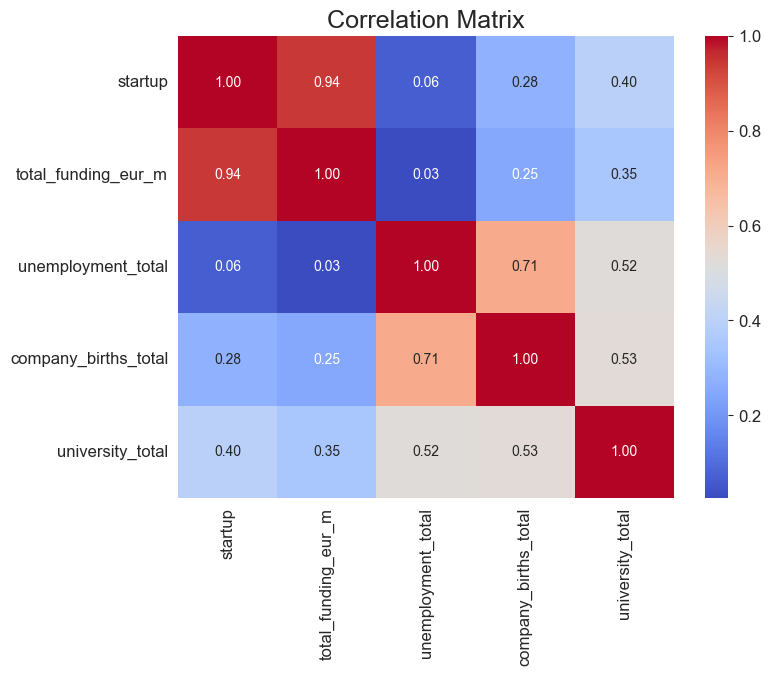

In [168]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

_At the end of the day, we can say that startups are geographically concentrated and appear moderately associated with higher education ecosystems, while unemployment shows little relationship with startup concentration._

### 6.3 Visual Exploration of Key Relationships

The following visualizations help illustrate the relationships identified in the correlation analysis. The charts are divided into a Funding perpective and a Startup perpective.

### Funding vs University Presence

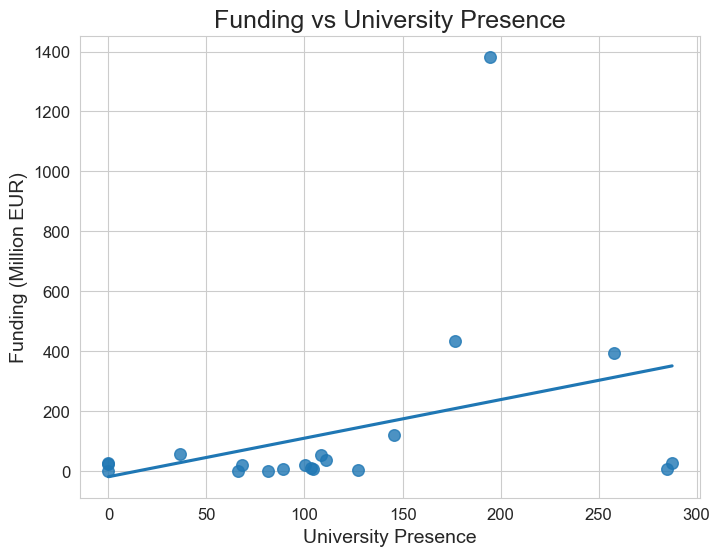

In [169]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=master_dataframe,
    x="university_total",
    y="total_funding_eur_m",
    scatter_kws={"s": 70},
    ci=None
)

plt.title("Funding vs University Presence")
plt.xlabel("University Presence")
plt.ylabel("Funding (Million EUR)")

plt.show()

### Funding vs Company Births

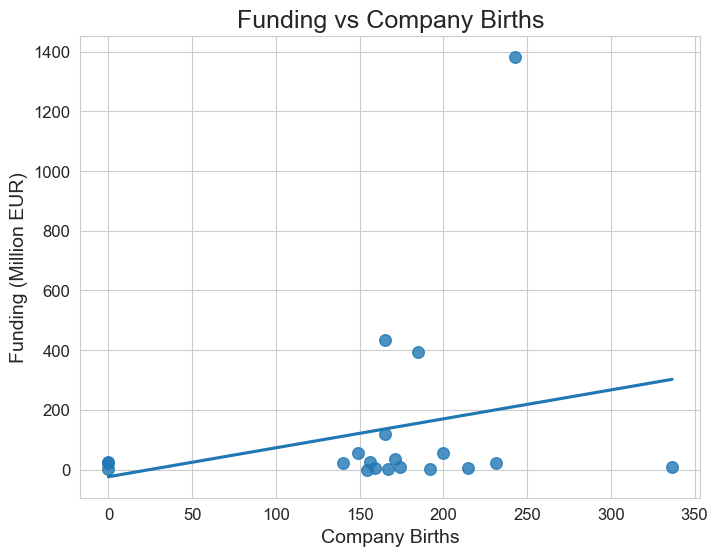

In [170]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=master_dataframe,
    x="company_births_total",
    y="total_funding_eur_m",
    scatter_kws={"s": 70},
    ci=None
)

plt.title("Funding vs Company Births")
plt.xlabel("Company Births")
plt.ylabel("Funding (Million EUR)")

plt.show()

### Funding vs Unemployment

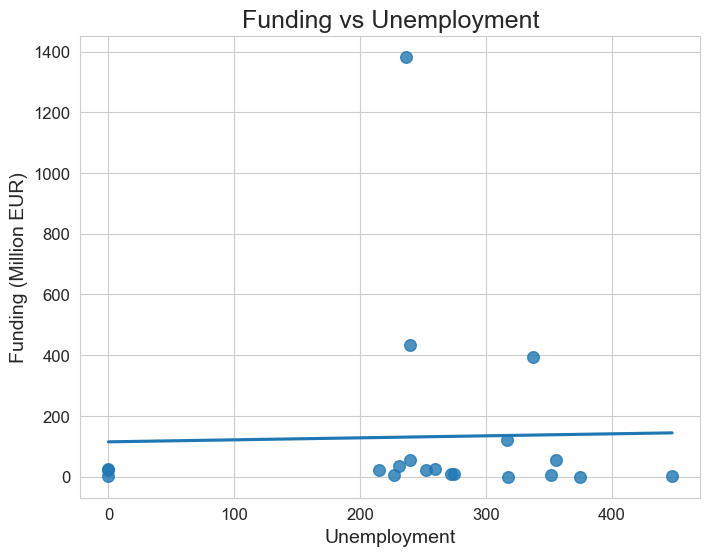

In [171]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=master_dataframe,
    x="unemployment_total",
    y="total_funding_eur_m",
    scatter_kws={"s": 70},
    ci=None
)

plt.title("Funding vs Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Funding (Million EUR)")

plt.show()

### Startups vs Universities

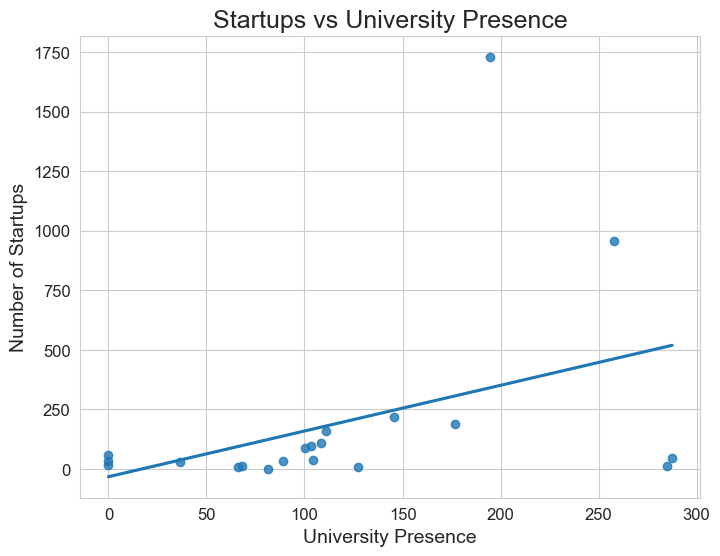

In [172]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=master_dataframe,
    x="university_total",
    y="startup",
    ci=None
)

plt.title("Startups vs University Presence")
plt.xlabel("University Presence")
plt.ylabel("Number of Startups")

plt.show()

### Startups vs Company Births

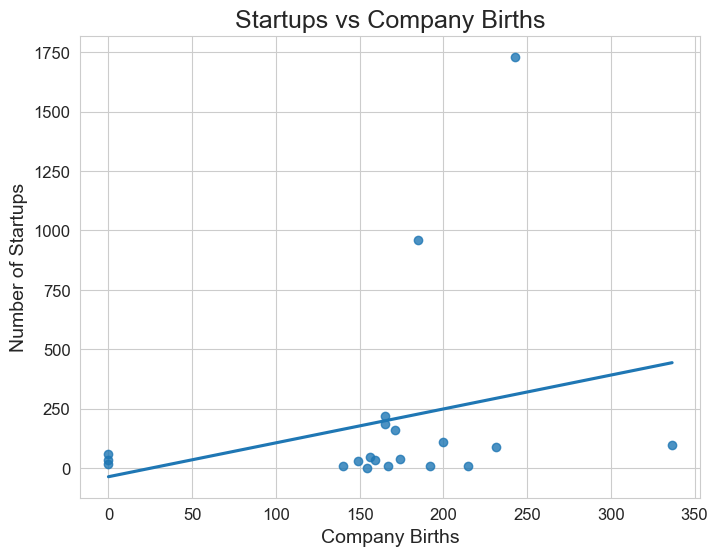

In [173]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=master_dataframe,
    x="company_births_total",
    y="startup",
    ci=None
)

plt.title("Startups vs Company Births")
plt.xlabel("Company Births")
plt.ylabel("Number of Startups")

plt.show()

### Startup vs Unemployment

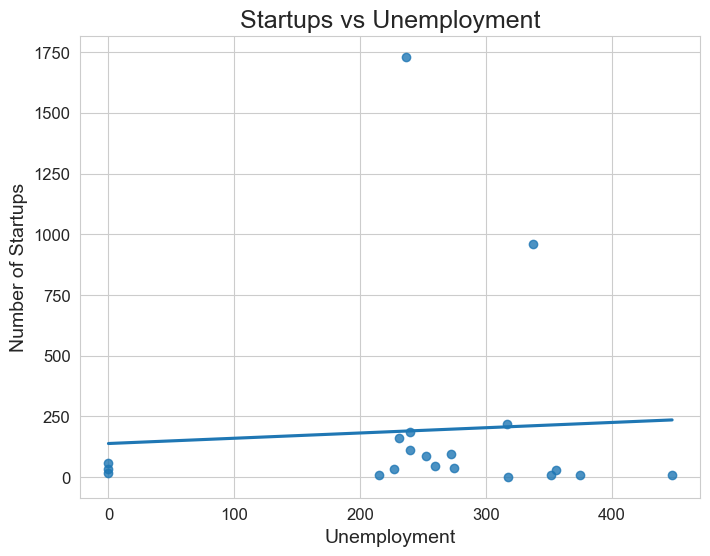

In [174]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=master_dataframe,
    x="unemployment_total",
    y="startup",
    ci=None
)

plt.title("Startups vs Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Number of Startups")

plt.show()

### Interpretation of Relationships

> The regression plots visually reinforce several of the relationships identified previously in the correlation analysis.
> 
> A positive relationship can be observed between startup concentration and university presence, suggesting that regions with stronger higher education ecosystems also tend to present higher entrepreneurial activity. A similar, although weaker, pattern appears between startup concentration and general business creation.
> 
> On the other hand, unemployment does not appear to display a clear visual relationship with startup concentration, reinforcing the idea that startup ecosystems may depend more heavily on innovation capacity, investment attraction, and economic dynamism than on labor market conditions alone.
> 
> The plots also highlight the presence of significant territorial asymmetries, with Lisbon and Porto behaving as clear outliers when compared to the remaining Portuguese regions.


## 7. Geographic Analysis

### 7.1 Startup Geographic Distribution

### Startup Concentration Map

In [175]:
#Keni data is set to work with municipalities yet. We already changed to regions in the rest of the project so for now, we will keep the municipality level and we will change it later. Lets create municipality_startups variable and use the "hq_city" column.
municipality_startups = (
    startups_dataframe
    .groupby("hq_city")
    .agg({
        "startup": "count"
    })
    .reset_index()
)

municipality_startups.columns = ["municipality", "startup_count"]

municipality_startups.head()

,municipality,startup_count
0,Abrantes,1
1,Albufeira,4
2,Alcanena,1
3,Alcobaça,5
4,Alcácer do Sal,4


### Municipality Startup Normalization

In [176]:
municipality_startups["municipality"] = (
    municipality_startups["municipality"]
    .str.upper()
    .apply(unidecode)
    .str.replace(" ", "-", regex=False)
)

### Choropleth Map for Startups by Municipality

In [177]:
plot_choropleth(
   municipality_startups,
   label="municipality",
   metric="startup_count",
   op="sum",
   title="Startup Concentration Across Portuguese Municipalities"
)

# Image("../figures/choropleth_lisbon_startups.png")

Map(center=[39.3999, -8.2245], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

In [184]:
plot_point_map(
    municipality_startups,
    label="municipality",
    metric="startup_count",
    title="Startup Distribution Across Portuguese Municipalities"
)

Map(center=[39.55838815794451, -8.313111959671472], controls=(ZoomControl(options=['position', 'zoom_in_text',…

### 7.2 Funding Geographic Distribution

### Funding Concentration Map

In [178]:
municipality_funding = (
    startups_dataframe
    .groupby("hq_city")
    .agg({
        "total_funding_eur_m": "sum"
    })
    .reset_index()
)

municipality_funding.columns = [
    "municipality",
    "funding"
]

### Municipality Funding normalization

In [179]:
municipality_funding["municipality"] = (
    municipality_funding["municipality"]
    .str.upper()
    .apply(unidecode)
    .str.replace(" ", "-", regex=False)
)

### Choropleth Map for Fundings by Municipality

In [180]:
municipality_funding

,municipality,funding
0,ABRANTES,0.31
1,ALBUFEIRA,0.00
2,ALCANENA,0.00
3,ALCOBACA,0.05
4,ALCACER-DO-SAL,0.00
...,...,...
158,VISEU,0.42
159,AGUEDA,0.00
160,EVORA,6.39
161,ILHAVO,14.91


In [181]:
plot_choropleth(
   municipality_funding,
   label="municipality",
   metric="funding",
   op="sum",
   title="Funding Distribution Across Portuguese Municipalities"
)

Map(center=[39.3999, -8.2245], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

In [182]:
plot_point_map(
    municipality_funding,
    label="municipality",
    metric="funding",
    title="Funding Distribution Across Portuguese Municipalities"
)

Map(center=[39.55838815794451, -8.313111959671472], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [183]:

# Image("../figures/choropleth_lisbon_fundings.png")

### Choropleth Map findings

> The choropleth maps reinforce the strong territorial concentration identified previously in the exploratory analysis.
> 
> Lisbon clearly dominates both startup concentration and funding attraction, while most municipalities display substantially lower levels of startup activity and investment.
> 
> These findings suggest that the Portuguese startup ecosystem remains highly centralized geographically.

## 8. Key Findings

1. The Portuguese startup ecosystem is highly concentrated geographically, with Lisbon and Porto clearly dominating both startup presence and funding attraction.

2. Funding concentration appears even stronger than startup concentration, suggesting that investment capital is heavily centralized in a small number of regions.

3. University presence shows a moderate positive relationship with startup concentration, supporting the idea that higher education ecosystems may contribute to entrepreneurial activity.

4. General business dynamism, measured through company births, also appears positively associated with startup concentration, although the relationship is weaker than expected. It gives an idea that everyone wants to be where everyone is.

5. Unemployment does not appear to have a strong relationship with startup concentration, suggesting that startup ecosystems may depend more on innovation infrastructure and investment environments than on labor market conditions.


## 9. Recommendations

Based on the findings of this analysis, some recommendations might be important for strengthening the Portuguese startup ecosystem across the country:

* Promote regional startup hubs outside Lisbon and Porto in order to reduce territorial concentration and stimulate local innovation ecosystems.

* Strengthen partnerships between universities and startups, particularly in regions with lower entrepreneurial activity.

* Improve access to funding opportunities in less represented regions to encourage startup creation and growth beyond the main urban centers.

* Support local business ecosystems and incubators capable of fostering entrepreneurial networks at the regional level.

* Continue investing in education, innovation, and technological infrastructure, as these factors appear positively associated with startup concentration.


## 10. Limitations

This project might present some limitations that should be considered when interpreting the findings.

First, the analysis relies on available public datasets, which may contain inconsistencies, missing values, or differences in territorial aggregation.

Second, the study focuses mainly on exploratory data analysis and correlation patterns rather than causal inference. Therefore, relationships identified between variables should not be interpreted as direct causal effects. Additionally, the analysis was conducted at a regional and municipal level, which may hide important local dynamics within regions.

Finally, the study focuses on the Portuguese startup ecosystem in 2023 because it was the common year between all the datasets, meaning that results may evolve over time as economic and entrepreneurial conditions change.


## 11. Conclusion

This project explored the geographic distribution of startups across Portugal and analyzed several socio-economic factors potentially associated with startup concentration.

The analysis confirmed the initial assumption that startup activity is strongly concentrated in Lisbon and Porto. These regions not only host a substantially larger number of startups, but also attract a disproportionately high share of investment funding.

The findings suggest that university presence and broader business dynamism may contribute positively to startup ecosystems, while unemployment does not appear to play a significant role in explaining startup concentration.

Overall, the Portuguese startup ecosystem appears highly centralized geographically, reinforcing the importance of regional innovation policies capable of fostering entrepreneurial development beyond the main metropolitan areas.
